In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

import os
os.getcwd()

# os.chdir("/home/jovyan/work/CN_A1_StructuralDescriptors")
os.chdir("/home/jovyan/work")
print(os.getcwd())
print(os.listdir())


/home/jovyan/work
['.git', 'A1-Log-Log-Histograms.pdf', 'activityA1', 'notebooks']


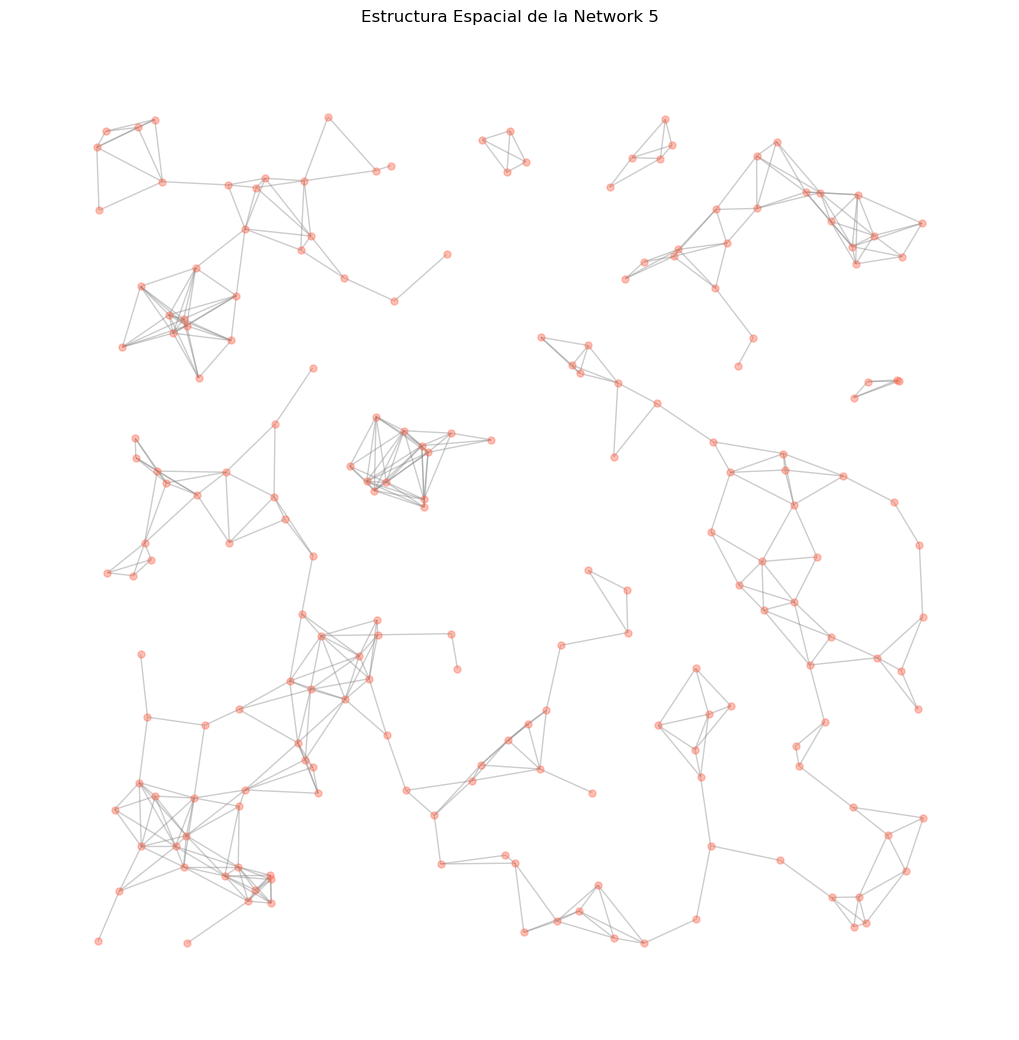

¿Está conectada?: False
Nodos dibujados: 200 de 200


In [2]:
G5_raw = nx.read_pajek('activityA1/net5.net')
G5 = nx.Graph(G5_raw)


pos_df = pd.read_csv('activityA1/positions_net5.txt', sep='\s+')


pos_dict = {}
for i in range(len(pos_df)):
    node_raw = pos_df.iloc[i, 0]
    node_x = float(pos_df.iloc[i, 1])
    node_y = float(pos_df.iloc[i, 2])
    
    node_id = str(int(node_raw))
    pos_dict[node_id] = (node_x, node_y)


nodes_with_pos = [n for n in G5.nodes() if n in pos_dict]
G5_sub = G5.subgraph(nodes_with_pos)

plt.figure(figsize=(10, 10))
nx.draw(G5_sub, pos=pos_dict, 
        node_size=25, 
        node_color='tomato', 
        edge_color='gray', 
        alpha=0.4, 
        with_labels=False)

plt.title("Estructura Espacial de la Network 5")
plt.show()

print(f"¿Está conectada?: {nx.is_connected(G5_sub)}")
print(f"Nodos dibujados: {len(nodes_with_pos)} de {len(G5.nodes())}")

## Network 5

In [3]:
G_raw = nx.read_pajek('activityA1/net5.net')
G = nx.Graph(G_raw)

### Part 1

#### Nodes & Edges

In [4]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print(num_nodes)
print(num_edges)

200
465


#### Min, Max and Avg degree

In [5]:
degrees = [degree for node, degree in G.degree()]
min_deg = np.min(degrees)
max_deg = np.max(degrees)
avg_deg = np.mean(degrees)
print(f"Grado mínimo: {min_deg}")
print(f"Grado máximo: {max_deg}")
print(f"Grado promedio: {avg_deg:.2f}")

Grado mínimo: 1
Grado máximo: 10
Grado promedio: 4.65


#### Avg clustering coeficient

In [6]:
avg_clustering = nx.average_clustering(G)
print(f"Average clustering: {avg_clustering:.4f}")

transitivity = nx.transitivity(G)
print(f"Transitivity: {transitivity:.4f}")

Average clustering: 0.6107
Transitivity: 0.6377


#### Assortativity

In [32]:
assortativity = nx.degree_assortativity_coefficient(G)
print(f"Assortativity: {assortativity:.4f}")

Assortativity: 0.5502


#### Average path lenght & Diameter

In [33]:
if nx.is_connected(G):
    G_main = G
else:
    print("Net is disconected")
    largest_cc = max(nx.connected_components(G), key=len)
    G_main = G.subgraph(largest_cc)

avg_path = nx.average_shortest_path_length(G_main)
diameter = nx.diameter(G_main)
print(f"Average path lenght {avg_path:.4f}")
print(f"Diameter: {diameter}")


Net is disconected
Average path lenght 13.1310
Diameter: 35


#### Degree distribution

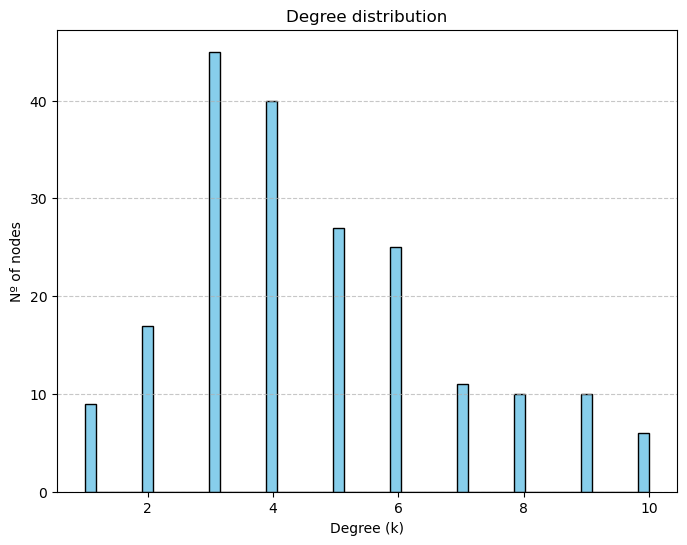

In [34]:
degrees = [degree for node, degree in G.degree()]

plt.figure(figsize=(8, 6))

plt.hist(degrees, bins=50, color='skyblue', edgecolor='black')

plt.title('Degree distribution')
plt.xlabel('Degree (k)')
plt.ylabel('Nº of nodes')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Degree centrality

In [35]:
def get_top_5(centrality_dict):
    return sorted(centrality_dict.items(), key=lambda item: item[1], reverse=True)[:5]

deg_cent = nx.degree_centrality(G)
print("\nTop 5 - Degree Centrality:")
for node, val in get_top_5(deg_cent):
    print(f"Node {node}: {val:.4f}")


Top 5 - Degree Centrality:
Node 18: 0.0503
Node 33: 0.0503
Node 37: 0.0503
Node 126: 0.0503
Node 150: 0.0503


#### Eigenvector centrality

In [36]:
try:
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
    print("\nTop 5 - Eigenvector Centrality:")
    for node, val in get_top_5(eig_cent):
        print(f"Node {node}: {val:.4f}")
except nx.PowerIterationFailedConvergence:
    print("\nFailed on convergence")


Top 5 - Eigenvector Centrality:
Node 126: 0.3459
Node 150: 0.3459
Node 3: 0.3366
Node 130: 0.3366
Node 160: 0.3366


#### Betweeness centrality

In [37]:
bet_cent = nx.betweenness_centrality(G) 
print("\nTop 5 - Betweenness Centrality:")
for node, val in get_top_5(bet_cent):
    print(f"Node {node}: {val:.4f}")


Top 5 - Betweenness Centrality:
Node 177: 0.1955
Node 129: 0.1933
Node 78: 0.1926
Node 84: 0.1926
Node 104: 0.1923


### Part 2